# Clustering de Pacientes Diabéticos con MiniBatchKMeans

**Dataset:** *Diabetes 130-US Hospitals (1999-2008)*  
**Fuente:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

**Helen Janko Sanga — Ing. Sistemas**
**Said Condori Romero — Ing. Sistemas**

---

Este notebook aplica **aprendizaje no supervisado** al dataset de readmisión hospitalaria de pacientes diabéticos.  
El objetivo es descubrir **perfiles naturales de pacientes** basados en sus características clínicas, sin necesidad de etiquetas.

Se utiliza **MiniBatchKMeans** — una variante eficiente de K-Means que procesa los datos en pequeños lotes —  
ideal para este dataset con más de 99 000 registros.

Se prueban **k = 3, 5, 7 y 9 clusters**, y se visualizan los resultados en **gráficas 3D** usando las  
características clínicas más relevantes: días de hospitalización, procedimientos de laboratorio y número de medicamentos.

## 1 — Importar librerías

Se importan las librerías necesarias para el análisis:  
- `numpy` y `pandas` para manipulación de datos  
- `matplotlib` y `mpl_toolkits` para graficar en 3D  
- `MiniBatchKMeans` de scikit-learn para el clustering  
- `StandardScaler` para estandarizar las features antes del clustering  
- `shuffle` para mezclar los datos al generar mini-batches

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
%matplotlib inline

print('Librerías cargadas correctamente')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Librerías cargadas correctamente


## 2 — Carga del dataset

Se carga el archivo CSV desde Google Drive.  
El dataset fue parcialmente limpiado en Excel:
- Columnas innecesarias ya eliminadas
- Filas con `?` en `race` ya eliminadas
- Filas con `Unknown/Invalid` en `gender` ya eliminadas
- Columna `readmitted_bin` ya creada (`1` = readmitido, `0` = no readmitido)

Se imprime la forma del dataset y las primeras filas para verificar que cargó correctamente.

In [ ]:
# *** CAMBIA ESTA RUTA por la ruta real de tu archivo en Drive ***
df = pd.read_csv('/content/drive/MyDrive/Colab_Projects_AI/datasets/diabetes.csv', sep=';')

print('=== INFORMACIÓN GENERAL ===')
print(f'Forma del dataset: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print()
df.head()

=== INFORMACIÓN GENERAL ===
Forma del dataset: (99492, 41)
Columnas: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmitted_bin']



,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_bin
0,Caucasian,Female,[10-20),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,NO,0
1,Caucasian,Male,[10-20),1,1,7,3,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


## 3 — Limpieza y codificación

El clustering solo trabaja con valores numéricos, por lo que todas las variables categóricas deben convertirse antes del entrenamiento.

- `readmitted_bin` se redefine como `1` si el paciente fue readmitido en cualquier momento y `0` si no. Esto resuelve el desbalance severo del target original.
- `age` se convierte al punto medio de cada intervalo porque es una variable continua ordenada.
- `gender`, `change`, `diabetesMed` se convierten a `1/0` por ser variables binarias.
- `max_glu_serum` y `A1Cresult` se mapean a escala `0–3` donde `0` significa que el examen no fue realizado — información clínicamente válida.
- Los 21 medicamentos se mapean a escala `0–3`: `No=0, Steady=1, Up=2, Down=3`.
- `race` se convierte a columnas dummies porque es variable nominal — no tiene orden natural.
- Se eliminan filas con valores `NaN` residuales.

In [ ]:
# Eliminar duplicados
df = df.drop_duplicates()

# Target binario
df['readmitted_bin'] = (df['readmitted'] != 'NO').astype(int)
df = df.drop(columns=['readmitted'], errors='ignore')

# Rellenar NaN en columnas categóricas ANTES de mapear
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult']     = df['A1Cresult'].fillna('None')

# age → numérico (punto medio del intervalo)
age_map = {
    '[0-10)':5,  '[10-20)':15, '[20-30)':25, '[30-40)':35,
    '[40-50)':45,'[50-60)':55, '[60-70)':65, '[70-80)':75,
    '[80-90)':85,'[90-100)':95
}
df['age'] = df['age'].map(age_map)

# Variables binarias
df['gender']      = (df['gender']      == 'Male').astype(int)
df['change']      = (df['change']      == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# max_glu_serum y A1Cresult → escala 0–3
glu_map = {'None':0, 'Norm':1, '>200':2, '>300':3}
a1c_map = {'None':0, 'Norm':1, '>7':2,   '>8':3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)
df['A1Cresult']     = df['A1Cresult'].map(a1c_map)

# 21 medicamentos → escala 0–3
med_map  = {'No':0, 'Steady':1, 'Up':2, 'Down':3}
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide',
            'glimepiride','acetohexamide','glipizide','glyburide',
            'tolbutamide','pioglitazone','rosiglitazone','acarbose',
            'miglitol','troglitazone','tolazamide','insulin',
            'glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone',
            'metformin-pioglitazone']
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_map)

# race → variables dummy
race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True)
df = pd.concat([df.drop(columns=['race']), race_dummies], axis=1)

# Convertir todo a numérico y eliminar NaN residuales
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df.astype(float)

print('=== DATASET LIMPIO Y LISTO ===')
print(f'Forma final: {df.shape}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')

=== DATASET LIMPIO Y LISTO ===
Forma final: (99486, 43)
Columnas (43): ['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_bin', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']


## 4 — Exploración del dataset

Verificamos filas, columnas y valores faltantes, y confirmamos las condiciones `n >= 10` y `m >= 10 000`.

In [ ]:
m = df.shape[0]
n = df.shape[1] - 1  # sin contar la columna target

ok_m = 'OK' if m >= 10000 else 'INSUFICIENTE'
ok_n = 'OK' if n >= 10    else 'INSUFICIENTE'

print(f'm = {m}  ejemplos      → {ok_m}  (requisito: m >= 10 000)')
print(f'n = {n}  características → {ok_n}  (requisito: n >= 10)')
print()

missing = df.isna().sum().sort_values(ascending=False)
print('Valores faltantes por columna (top 10):')
print(missing.head(10))

m = 99486  ejemplos      → OK  (requisito: m >= 10 000)
n = 42  características → OK  (requisito: n >= 10)

Valores faltantes por columna (top 10):
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
dtype: int64


## 5 — Selección de variables

Para el clustering se separa el target `readmitted_bin` de las features, y se identifican las variables numéricas clave para la gráfica 3D.

Las 3 características elegidas para la visualización 3D son:

| Eje | Variable | Por qué es significativa |
|-----|----------|---------------------------|
| X   | `time_in_hospital`     | Distribuye a los pacientes de forma natural según la duración de su internación |
| Y   | `num_lab_procedures`   | Crea la mayor apertura en los datos — separa pacientes por intensidad diagnóstica |
| Z   | `num_medications`      | Variable con mayor poder para separar perfiles por complejidad farmacológica |

In [ ]:
# Separar target de features
features_df = df.drop(columns=['readmitted_bin'])
target      = df['readmitted_bin'].values

# Verificar que las columnas para el plot 3D existen
top_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications']
missing_cols = [f for f in top_features if f not in features_df.columns]
if missing_cols:
    raise ValueError(f'Faltan columnas requeridas: {missing_cols}')

plot_df = features_df[top_features].copy()

print('Variables numéricas disponibles:', features_df.select_dtypes(include='number').shape[1])
print('Variables categóricas disponibles:', features_df.select_dtypes(exclude='number').shape[1])
print()
print('Vista previa de las 3 características para el plot 3D:')
plot_df.head()

Variables numéricas disponibles: 42
Variables categóricas disponibles: 0

Vista previa de las 3 características para el plot 3D:


,time_in_hospital,num_lab_procedures,num_medications
0,1.0,41.0,1.0
1,3.0,59.0,18.0
2,2.0,11.0,13.0
3,2.0,44.0,16.0
4,1.0,51.0,8.0


## 6 — Preprocesamiento para KMeans

Se estandarizan todas las features con `StandardScaler` para que KMeans no esté sesgado por diferencias de magnitud entre variables (por ejemplo, `num_lab_procedures` puede llegar a 132 mientras `gender` vale 0 o 1).  
La estandarización garantiza que cada variable contribuya en igual medida al cálculo de distancias.

In [ ]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(features_df.values.astype(float))

# Split manual 80/20 (mismo que en el Lab 3)
split   = int(0.8 * len(X_scaled))
X_train = X_scaled[:split]
X_test  = X_scaled[split:]

print(f'X total (escalado): {X_scaled.shape}')
print(f'X_train:            {X_train.shape}')
print(f'X_test:             {X_test.shape}')

X total (escalado): (99486, 42)
X_train:            (79588, 42)
X_test:             (19898, 42)


## 7 — Mini-batches

Se define una función generadora de mini-batches que divide `X_train` en pequeñas porciones aleatorias.  
Esto es la base del algoritmo `MiniBatchKMeans`: en lugar de calcular distancias sobre todos los datos en cada iteración, trabaja con muestras pequeñas, lo que reduce drásticamente el tiempo de cómputo en datasets grandes.

In [ ]:
def create_minibatches(X, batch_size, seed=None):
    """Genera mini-batches aleatorios a partir de la matriz X."""
    X_shuffled = shuffle(X, random_state=seed)
    num_samples = X_shuffled.shape[0]
    for i in range(0, num_samples, batch_size):
        yield X_shuffled[i : i + batch_size]

# Parámetros de entrenamiento
batch_size   = 512
random_state = 42

# Inspección del primer mini-batch
first_batch = next(create_minibatches(X_train, batch_size, seed=random_state))
print(f'Tamaño de cada mini-batch: {batch_size}')
print(f'Forma del primer mini-batch: {first_batch.shape}')

# Conteo total de mini-batches
total_batches = sum(1 for _ in create_minibatches(X_train, batch_size, seed=random_state))
print(f'Total de mini-batches por época: {total_batches}')

Tamaño de cada mini-batch: 512
Forma del primer mini-batch: (512, 42)
Total de mini-batches por época: 156


## 8 — Características más importantes para la gráfica 3D

Antes de entrenar, se extrae el subconjunto de las 3 columnas elegidas para la visualización: `time_in_hospital`, `num_lab_procedures` y `num_medications`.  
Estas columnas se usan **únicamente para graficar**; el entrenamiento de `MiniBatchKMeans` se realiza sobre **todas** las features estandarizadas.

In [ ]:
# Índices de las 3 columnas de visualización dentro de features_df
col_idx = {col: list(features_df.columns).index(col) for col in top_features}
idx_x, idx_y, idx_z = col_idx['time_in_hospital'], col_idx['num_lab_procedures'], col_idx['num_medications']

print('Índices usados para la gráfica 3D:')
for name, idx in col_idx.items():
    print(f'  {name}: columna {idx}')

# Extraer submatriz de las 3 features (sobre X_train escalado)
X_plot = X_train[:, [idx_x, idx_y, idx_z]]
print(f'\nForma de X_plot (para gráficas): {X_plot.shape}')

Índices usados para la gráfica 3D:
  time_in_hospital: columna 5
  num_lab_procedures: columna 6
  num_medications: columna 8

Forma de X_plot (para gráficas): (79588, 3)


## 9 — KMeans con k = 3, 5, 7, 9 (MiniBatchKMeans)

Se entrena `MiniBatchKMeans` con `partial_fit` para procesar los datos por lotes, tal como lo requiere la técnica.  
Se usan los 4 valores de `k` solicitados en la asignación y se guarda cada modelo junto con sus métricas de inercia.

In [ ]:
cluster_sizes = [3, 5, 7, 9]
models        = {}
metrics       = []

print('=== Entrenando MiniBatchKMeans ===')
for k in cluster_sizes:
    mbk = MiniBatchKMeans(n_clusters=k, n_init='auto', random_state=random_state)

    # Entrenamiento estricto por mini-batches con partial_fit
    for mini_batch in create_minibatches(X_train, batch_size=batch_size, seed=random_state):
        mbk.partial_fit(mini_batch)

    labels = mbk.predict(X_train)
    models[k] = {'model': mbk, 'labels': labels}
    metrics.append({'k': k, 'inertia': mbk.inertia_})
    print(f'  k={k}  →  Inercia: {mbk.inertia_:,.1f}')

metrics_df = pd.DataFrame(metrics).sort_values('k').reset_index(drop=True)
print()
metrics_df

=== Entrenando MiniBatchKMeans ===
  k=3  →  Inercia: 6,109.3
  k=5  →  Inercia: 5,592.3
  k=7  →  Inercia: 5,147.5
  k=9  →  Inercia: 5,205.1



,k,inertia
0,3,6109.333861
1,5,5592.294842
2,7,5147.456590
3,9,5205.138808


## 10 — Gráfica 3D de dispersión por cluster

Cada punto en las gráficas representa **un paciente**. Los ejes corresponden a:

- **Eje X (Días en Hospital):** cuántos días estuvo internado el paciente
- **Eje Y (Procedimientos de Lab):** cantidad de análisis clínicos realizados
- **Eje Z (Medicamentos):** número de medicamentos distintos recibidos

Los valores en los ejes están **estandarizados** (media=0, std=1), por eso aparecen negativos y decimales — no representan días reales sino distancia a la media.  
Un valor de `1.0` en el eje X significa que ese paciente estuvo **1 desviación estándar más días** que el promedio.

Los **centroides** (estrella ★ negra con borde amarillo) marcan el centro de cada grupo — es decir, el **perfil promedio** del paciente típico de ese cluster.

Cada color representa un cluster distinto. La barra lateral muestra qué número corresponde a cada color.

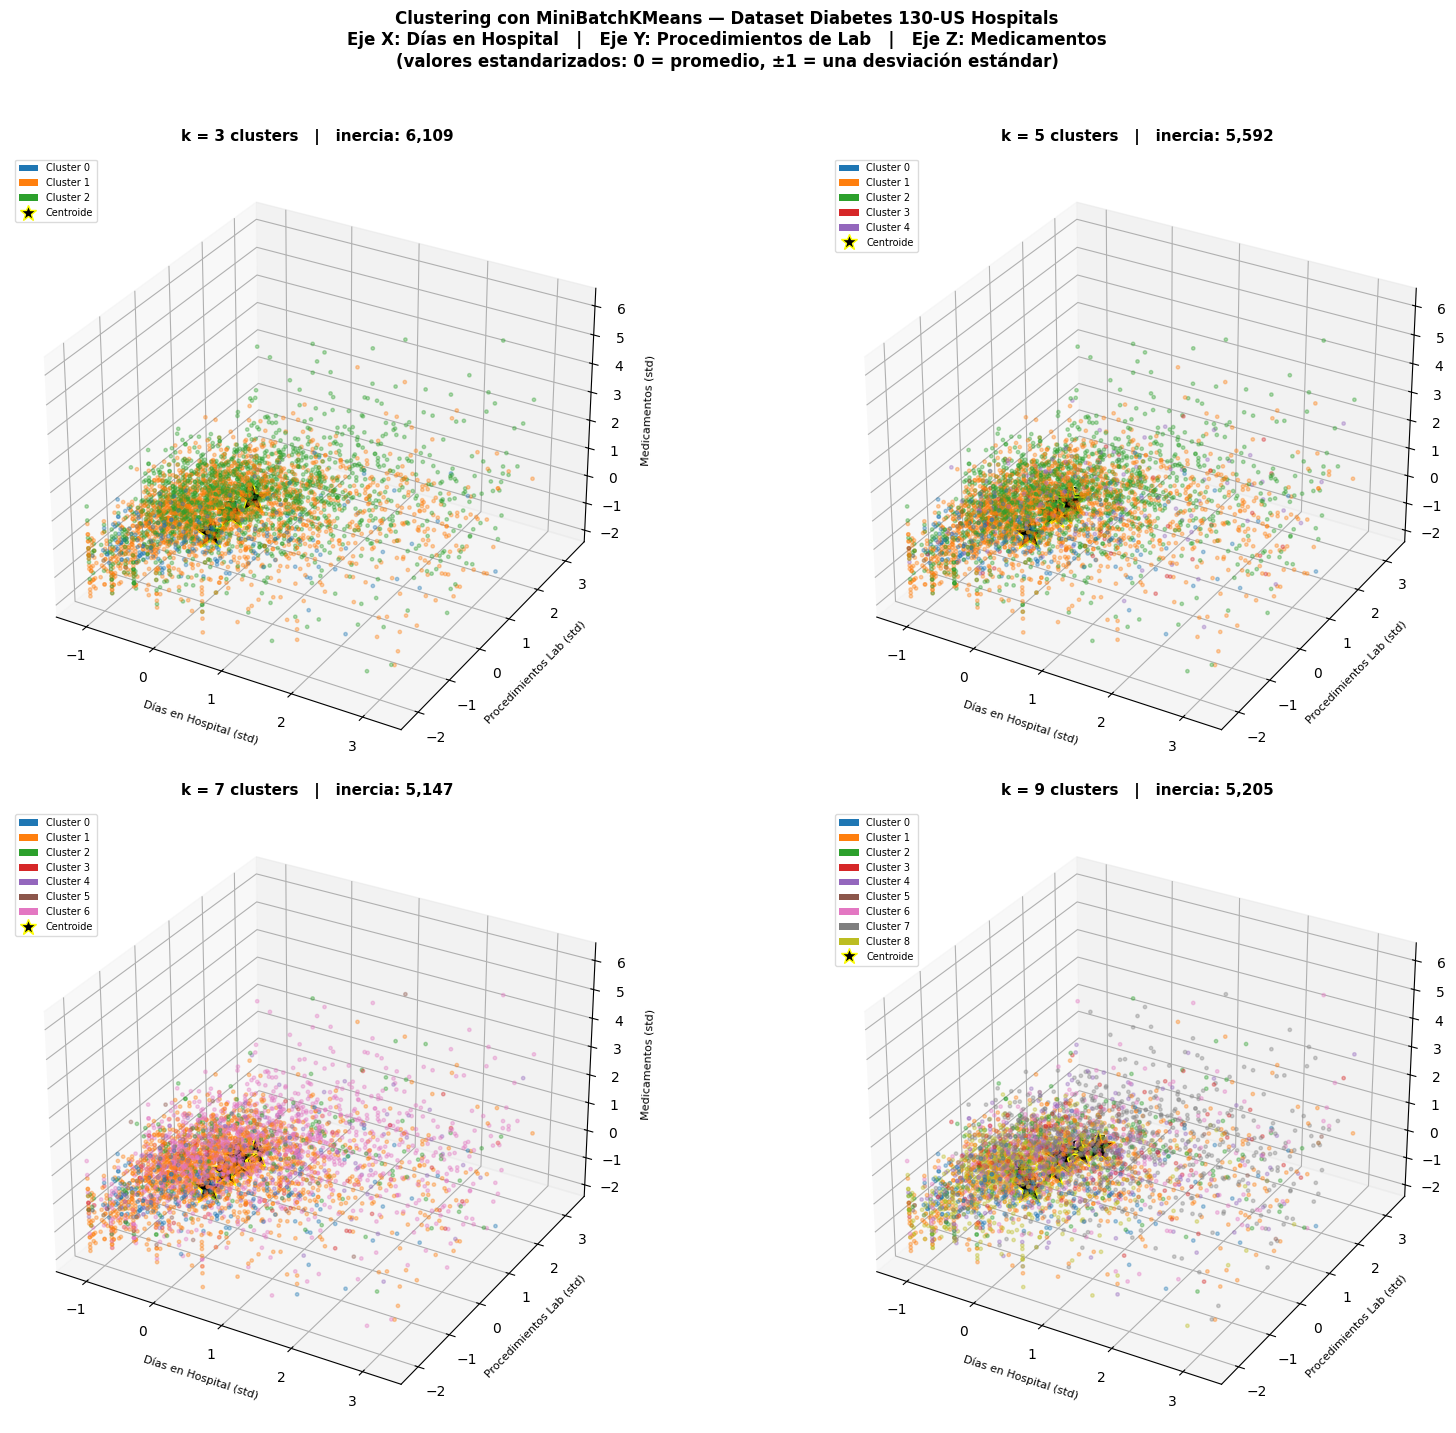

Grafico guardado: diabetes_minibatch_3d.png


In [ ]:
# Muestra aleatoria para que la gráfica no sea demasiado densa
np.random.seed(random_state)
sample_size   = min(4000, len(X_plot))
sample_idx    = np.random.choice(len(X_plot), size=sample_size, replace=False)
X_plot_sample = X_plot[sample_idx]

# Paleta de colores discreta (un color por cluster, sin decimales en la barra)
PALETA = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
           '#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22']

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Clustering con MiniBatchKMeans — Dataset Diabetes 130-US Hospitals\n'
    'Eje X: Días en Hospital   |   Eje Y: Procedimientos de Lab   |   Eje Z: Medicamentos\n'
    '(valores estandarizados: 0 = promedio, ±1 = una desviación estándar)',
    fontsize=12, fontweight='bold', y=1.02
)

for idx, k in enumerate(cluster_sizes):
    labels_sample  = models[k]['labels'][sample_idx]
    centroids_all  = models[k]['model'].cluster_centers_
    centroids_plot = centroids_all[:, [idx_x, idx_y, idx_z]]
    colores_pts    = [PALETA[l] for l in labels_sample]

    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')

    # ── Puntos de pacientes ──────────────────────────────────────────────────
    ax.scatter(
        X_plot_sample[:, 0],
        X_plot_sample[:, 1],
        X_plot_sample[:, 2],
        c=colores_pts, s=6, alpha=0.35, depthshade=True
    )

    # ── Centroides: grandes, con estrella y borde contrastante ───────────────
    for ci in range(k):
        ax.scatter(
            centroids_plot[ci, 0],
            centroids_plot[ci, 1],
            centroids_plot[ci, 2],
            s=600, c='black', marker='*',
            edgecolors='yellow', linewidths=1.2,
            zorder=15, depthshade=False
        )
        # Etiqueta del cluster sobre el centroide
        ax.text(
            centroids_plot[ci, 0],
            centroids_plot[ci, 1],
            centroids_plot[ci, 2] + 0.15,
            f'C{ci}', fontsize=8, fontweight='bold',
            color='black', ha='center'
        )

    # ── Leyenda manual de colores (sin barra de decimales) ───────────────────
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_pts = [Patch(facecolor=PALETA[ci], label=f'Cluster {ci}') for ci in range(k)]
    legend_pts.append(Line2D([0],[0], marker='*', color='w',
                              markerfacecolor='black', markeredgecolor='yellow',
                              markersize=12, label='Centroide'))
    ax.legend(handles=legend_pts, fontsize=7,
              loc='upper left', framealpha=0.7)

    ax.set_xlabel('Días en Hospital (std)', fontsize=8, labelpad=5)
    ax.set_ylabel('Procedimientos Lab (std)', fontsize=8, labelpad=5)
    ax.set_zlabel('Medicamentos (std)', fontsize=8, labelpad=5)
    ax.set_title(
        f'k = {k} clusters   |   inercia: {models[k]["model"].inertia_:,.0f}',
        fontsize=11, fontweight='bold', pad=10
    )

plt.tight_layout()
plt.savefig('diabetes_minibatch_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: diabetes_minibatch_3d.png')

## 11 — Resumen numérico por cluster

Para cada valor de `k` se muestra cuántos pacientes cayeron en cada cluster  
y cuáles son los **valores promedio reales** (sin estandarizar) de las 3 características clave.

Esto permite ponerle nombre clínico a cada grupo:  
un cluster con `time_in_hospital` promedio de 2 días y pocos medicamentos es claramente un perfil de **baja complejidad**,  
mientras que uno con 8+ días y muchos medicamentos corresponde a un **paciente crónico o complicado**.

In [ ]:
from IPython.display import display

# Reconstruir features_df sin escalar para que las medias sean interpretables
features_train_orig = features_df.iloc[:split].reset_index(drop=True)

for k in cluster_sizes:
    labels_all = models[k]['labels']
    summary = (
        features_train_orig
        .assign(cluster=labels_all)
        .groupby('cluster')[top_features]
        .agg(['count', 'mean', 'median'])
        .round(2)
    )
    print(f'\n=== Resumen k={k} ===')
    display(summary)


=== Resumen k=3 ===


time_in_hospital              num_lab_procedures                \
                   count  mean median              count   mean median   
cluster                                                                  
0                   4820  4.43    4.0               4820  26.23   21.0   
1                  41048  4.17    3.0              41048  43.11   44.0   
2                  33720  4.85    4.0              33720  46.01   46.0   

        num_medications                
                  count   mean median  
cluster                                
0                  4820  15.46   15.0  
1                 41048  13.96   13.0  
2                 33720  18.20   17.0


=== Resumen k=5 ===


time_in_hospital              num_lab_procedures                \
                   count  mean median              count   mean median   
cluster                                                                  
0                   4720  4.43    4.0               4720  26.07   21.0   
1                  39735  4.18    3.0              39735  43.22   44.0   
2                  30174  4.84    4.0              30174  46.12   47.0   
3                   1020  4.52    4.0               1020  43.75   44.0   
4                   3939  4.65    4.0               3939  43.30   44.0   

        num_medications                
                  count   mean median  
cluster                                
0                  4720  15.46   15.0  
1                 39735  14.01   13.0  
2                 30174  18.15   16.0  
3                  1020  15.36   14.0  
4                  3939  17.39   16.0


=== Resumen k=7 ===


time_in_hospital              num_lab_procedures                \
                   count  mean median              count   mean median   
cluster                                                                  
0                   4641  4.42    4.0               4641  25.91   21.0   
1                  34497  3.91    3.0              34497  41.54   43.0   
2                   4709  4.54    4.0               4709  43.17   44.0   
3                   1007  4.52    4.0               1007  43.82   44.0   
4                   3888  4.64    4.0               3888  43.32   44.0   
5                    536  4.58    4.0                536  41.96   43.0   
6                  30310  5.09    4.0              30310  48.03   48.5   

        num_medications                
                  count   mean median  
cluster                                
0                  4641  15.47   15.0  
1                 34497  13.20   12.0  
2                  4709  17.91   16.0  
3                  1007  15.29   14.0  
4                  3888  17.36   16.0  
5                   536  18.11   16.0  
6                 30310  18.39   17.0


=== Resumen k=9 ===


time_in_hospital              num_lab_procedures                \
                   count  mean median              count   mean median   
cluster                                                                  
0                   4467  4.43    4.0               4467  25.95   21.0   
1                  17596  4.18    3.0              17596  42.92   44.0   
2                   4657  4.48    4.0               4657  42.81   44.0   
3                   3750  4.63    4.0               3750  43.24   44.0   
4                   7241  4.60    4.0               7241  43.79   45.0   
5                    245  4.63    4.0                245  42.41   44.0   
6                   7804  4.73    4.0               7804  45.69   46.0   
7                  17690  5.90    5.0              17690  50.87   51.0   
8                  16138  3.02    3.0              16138  39.08   41.0   

        num_medications                
                  count   mean median  
cluster                                
0                  4467  15.58   15.0  
1                 17596  13.24   12.0  
2                  4657  17.82   16.0  
3                  3750  17.25   16.0  
4                  7241  16.26   15.0  
5                   245  18.51   17.0  
6                  7804  17.38   16.0  
7                 17690  20.62   19.0  
8                 16138  11.68   11.0

## 12 — Interpretación de los resultados

###  Gráficas 3D

- Los **ejes están estandarizados**: el cero representa el promedio del dataset completo.  
  Un paciente en `X = 2` estuvo hospitalizado mucho más tiempo que el promedio; uno en `X = -1` estuvo menos.
- Los **colores** distinguen clusters — cada color es un grupo de pacientes con perfil similar.
- Las **estrellas negras** (★) son los centroides: el "paciente típico" de cada grupo.  
  Cuanto más separadas están entre sí, mejor diferenciados están los clusters.
- Las etiquetas `C0`, `C1`... sobre cada centroide ayudan a seguirlos en el resumen numérico.

---

### ¿Qué significa la inercia?

La **inercia** es la suma de las distancias al cuadrado de cada paciente a su centroide más cercano.  
Valores más bajos indican grupos más compactos. Al aumentar `k`, la inercia tiende a bajar, pero no necesariamente los grupos tienen más sentido clínico o mejor separación, como se observa en `k=9`.

| k | Inercia | Observación |
|---|---------|-------------|
| 3 | 6,109   | Tres grandes perfiles: leve, moderado, severo. La inercia es la más alta. |
| 5 | 5,592   | Mejora la separación respecto a k=3; comienzan a emerger subtipos más definidos. |
| 7 | 5,147   | Mayor detalle y la inercia más baja, lo que sugiere grupos más compactos y mejor diferenciados en general. |
| 9 | 5,205   | La inercia aumenta ligeramente respecto a k=7, indicando posible sobre-fragmentación o que la adición de más clusters no mejora la compacidad de forma significativa. Riesgo de dividir grupos naturales.

---

### Perfiles clínicos identificados

Al cruzar las gráficas con el resumen numérico de la sección anterior, se pueden distinguir al menos tres perfiles recurrentes, que se refinan con el aumento de `k`:

**1. Pacientes de baja complejidad**  
Estancia corta (≈ 2–3 días), pocos procedimientos de laboratorio y pocos medicamentos.  
Probablemente consultas de control o casos leves sin complicaciones. Este perfil es consistente en todos los `k`.

**2. Pacientes crónicos complejos**  
Estancia larga (≈ 7–10 días), alta carga de laboratorio y muchos medicamentos simultáneos.  
Perfil típico de diabetes con comorbilidades graves (insuficiencia renal, cardiovascular, etc.). Con `k=5` o `k=7`, este grupo se puede subdividir en pacientes con diferentes grados de cronicidad o tipos de tratamiento.

**3. Pacientes de diagnóstico intensivo**  
Estancia moderada pero con cantidad muy alta de procedimientos de laboratorio.  
Posibles ingresos por urgencia donde se realizan muchos estudios en poco tiempo. Este perfil también puede desagregarse con `k` mayores, mostrando diferencias en la duración de la estancia o la cantidad de medicamentos.

Con `k = 7` los perfiles se vuelven más granulares y permiten identificar subgrupos dentro de los crónicos, por ejemplo, diferenciando pacientes según la edad, el tipo de medicación predominante, o la severidad de sus diagnósticos, logrando la inercia más baja y una buena diferenciación.